In [1]:
import re
import wiki_dump_parser as parser
import pandas as pd
import matplotlib.pyplot as plt
import wikitextparser as wtp
from sklearn.model_selection import train_test_split

## Run only once to convert to parquet

In [ ]:
parser.xml_to_csv('data/wikipedia-ukr/ukwiki-20250401-pages-articles-multistream.xml')

In [5]:
df = pd.read_csv('data/wikipedia-ukr/ukwiki-20250401-pages-articles-multistream.csv', index_col=False)

df.to_parquet("all_articles.parquet", engine="pyarrow", index=False, compression="snappy")

## Infer statistics for the articles

In [2]:
df = pd.read_parquet("all_articles.parquet", engine="pyarrow", columns=["page_id", "page_title", "bytes"])

df.describe()

,page_id,bytes
count,3.159887e+06,3.159887e+06
mean,2.691097e+06,4.134998e+03
std,1.585186e+06,1.299878e+04
min,2.000000e+00,0.000000e+00
25%,1.283104e+06,7.400000e+01
50%,2.654747e+06,5.390000e+02
75%,4.019140e+06,4.464000e+03
max,5.490240e+06,1.859489e+06


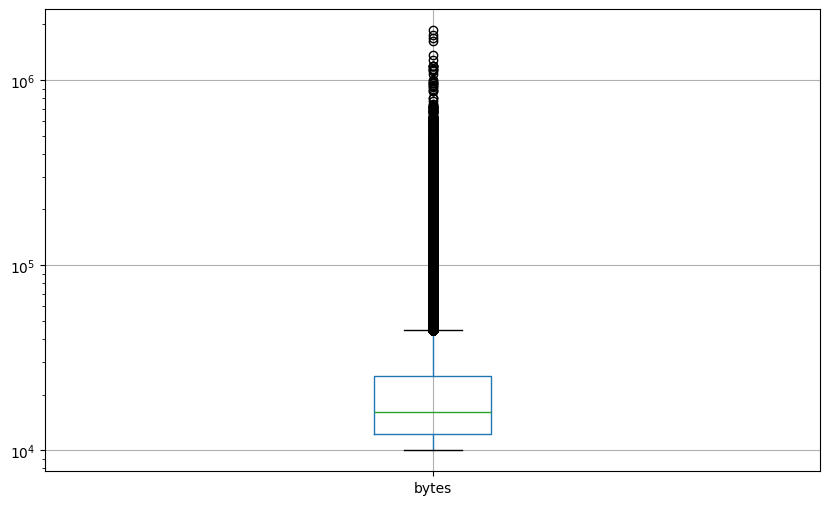

In [4]:
plt.figure(figsize=(10, 6))
df_tmp = df[df["bytes"] > 1e4]
df_tmp.boxplot(column="bytes", ax=plt.gca())
plt.yscale("log")
plt.show()

In [55]:
df = pd.read_parquet("all_articles.parquet", engine="pyarrow", columns=["page_id", "page_title", "bytes", "text"],
                     filters=[("bytes", ">", 1e4)])

df

,page_id,page_title,bytes,text
0,13,Географія,83231,{{Географія вертикальний |image=Physical world...
1,584,Атом,63656,{{Оновити-ДС}}{{Otheruses|Атом (значення)}}\n[...
2,586,Ядро,14214,{{disambig}}\n'''Ядро́'''&nbsp;— основна части...
3,588,Хімія,50064,'''Хі́мія''' або '''хе́мія'''<ref>Глосарій тер...
4,590,Діаметр,24045,[[Файл:Circle with radius and diameter.png|thu...
...,...,...,...,...
295000,5490097,Lord Marksman and Vanadis,48304,{{Картка:Аніманґа/Заголовок\n| зображення ...
295001,5490178,Поїзд до Дарджилінга,20246,\n{{Картка:Фільм\n| назва = Поїзд ...
295002,5490179,Фотометрична система,22489,'''Фотометрична система'''&nbsp;— це набір чіт...
295003,5490181,Хіраясумі,14151,{{Infobox animanga/Header\n| image =...


In [56]:
def make_drop_mask(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series([False] * len(df))
    mask[df["page_title"].str.contains(r"Категорія|Шаблон|Вікіпедія|Файл|\(Значення\)", na=False)] = True
    mask[df["page_title"].str.contains("Довідка|Вікіпедія:|Вікіпедія:Список|Вікіпедія:Шаблон|Вікіпедія:Файл|Вікіпедія:Гумор", na=False)] = True

    mask[df["page_title"].str.contains(r"\d{4}")] = True
    mask[df["page_title"].str.contains(r"\d{1,4}-ті")] = True
    mask[df["page_title"].str.contains(r"\d{1,2}\s(?:січня|лютого|березня|квітня|травня|червня|липня|серпня|вересня|жовтня|листопада|грудня)")] = True
    mask[df["page_title"].str.contains(r"\w{1,5} століття")] = True

    mask[df["page_title"].str.contains(r"^Міста \w+")] = True
    mask[df["page_title"].str.contains(r"^Села \w+")] = True
    mask[df["page_title"].str.contains(r"район$")] = True
    return mask
df_mask = make_drop_mask(df)

df[~df_mask]
# df[df_mask]

,page_id,page_title,bytes,text
0,13,Географія,83231,{{Географія вертикальний |image=Physical world...
1,584,Атом,63656,{{Оновити-ДС}}{{Otheruses|Атом (значення)}}\n[...
2,586,Ядро,14214,{{disambig}}\n'''Ядро́'''&nbsp;— основна части...
3,588,Хімія,50064,'''Хі́мія''' або '''хе́мія'''<ref>Глосарій тер...
4,590,Діаметр,24045,[[Файл:Circle with radius and diameter.png|thu...
...,...,...,...,...
295000,5490097,Lord Marksman and Vanadis,48304,{{Картка:Аніманґа/Заголовок\n| зображення ...
295001,5490178,Поїзд до Дарджилінга,20246,\n{{Картка:Фільм\n| назва = Поїзд ...
295002,5490179,Фотометрична система,22489,'''Фотометрична система'''&nbsp;— це набір чіт...
295003,5490181,Хіраясумі,14151,{{Infobox animanga/Header\n| image =...


In [57]:
df[~df_mask][:10000].to_parquet("articles_10k.parquet", engine="pyarrow", index=False, compression="snappy")

## Data cleanup script

Note the [Статті, які повинні бути у всіх Вікіпедіях](https://uk.wikipedia.org/wiki/%D0%92%D1%96%D0%BA%D1%96%D0%BF%D0%B5%D0%B4%D1%96%D1%8F:%D0%A1%D1%82%D0%B0%D1%82%D1%82%D1%96,_%D1%8F%D0%BA%D1%96_%D0%BF%D0%BE%D0%B2%D0%B8%D0%BD%D0%BD%D1%96_%D0%B1%D1%83%D1%82%D0%B8_%D0%B2_%D1%83%D1%81%D1%96%D1%85_%D0%92%D1%96%D0%BA%D1%96%D0%BF%D0%B5%D0%B4%D1%96%D1%8F%D1%85) article for automated selection

In [58]:
df = pd.read_parquet("articles_10k.parquet", engine="pyarrow")

df

,page_id,page_title,bytes,text
0,13,Географія,83231,{{Географія вертикальний |image=Physical world...
1,584,Атом,63656,{{Оновити-ДС}}{{Otheruses|Атом (значення)}}\n[...
2,586,Ядро,14214,{{disambig}}\n'''Ядро́'''&nbsp;— основна части...
3,588,Хімія,50064,'''Хі́мія''' або '''хе́мія'''<ref>Глосарій тер...
4,590,Діаметр,24045,[[Файл:Circle with radius and diameter.png|thu...
...,...,...,...,...
9995,57980,Каталог Мессьє,46990,[[Файл:Messier catalog first page.jpg|right|th...
9996,58018,Заставний Роман Йосипович,12171,{{otherpersons|Заставний}}\n{{Картка:Лідер \n|...
9997,58019,Мазепа,11291,{{Disambig}}\n'''Мазепа''' (від ''мазати'' і с...
9998,58029,Збірна Франції з футболу,111224,{{Картка:Збірна команда з футболу\n| Команда =...


In [49]:
article_example = df.iloc[0]["text"]

print(article_example)

{{Географія вертикальний |image=Physical world.jpg |caption=Фізична карта світу}}
'''Геогра́фія,''' або [[Активна і пасивна лексика української мови|заст.]] '''земле́пис'''<ref>{{r2u|землепис}}</ref> (від {{lang-grc|γεωγραφία}}&nbsp;— опис Землі; де {{lang-grc2|γεια}}&nbsp;— Земля і {{lang-grc2|γραφειν}}&nbsp;— писати, описувати<ref name="Etymology"/>)&nbsp;— [[наука|система наук]], що вивчає [[Географічна оболонка|географічну оболонку]] [[Земля (планета)|Землі]] (епігеосферу), її просторову природну і соціально-економічну різноманітність, господарство і населення планети, окремих її регіонів та країн, а також зв'язки між природним середовищем і діяльністю людини<ref name="Geography"/>. В сучасному розумінні поняття «географія» заміщено поняттям «географічні науки».

== Поняття ==
Уперше термін «географія» ввів давньогрецький географ [[Ератосфен]] (276—194 до н.&nbsp;е.)<ref name="УРЕ"/>.

== Структура ==
Основне завдання сучасної географії полягає у вивченні законів і закономірностей 

In [83]:
oddly_marked_galleries = re.compile(r"(:\s)?\{\|.+?\|\}", flags=re.DOTALL)
galleries_regex = re.compile(r"<gallery.+?>.+?<\/gallery>", flags=re.DOTALL)

title_regex = re.compile(r"=+ .+ =+$", flags=re.MULTILINE)

def cleanup_article(article: str) -> str:
    article = oddly_marked_galleries.sub("", article)
    article = galleries_regex.sub("", article)
    return article


def parse_template(template: wtp.Template) -> str:
    if template.name == "li":
        if len(template.arguments) == 2:
            return template.arguments[0].value

        return template.arguments[1].value

    if template.name.startswith("lang-") and len(template.arguments) >= 1:
        return template.arguments[0].value

    if template.name == "langx" and len(template.arguments) >= 2:
        return template.arguments[1].value

    if template.name == "Нп" and len(template.arguments) >= 2:
        return template.arguments[1].value

    return ""

def cleanup_section(text: str) -> str:
    # Made by Ostap
    text = re.sub(r'\s+', ' ', text).strip() # Redundats spamces

    text = re.sub(r'\s—\s\.', '', text) # — .

    text = re.sub(r'\{https.*?\}', '', text) # url
    text = re.sub(r'\(https.*?\)', '', text) # url
    text = re.sub(r'\[https.*?\]', '', text) # url

    text = re.sub(r'(\.){2,}', r'...', text) # period repetitions
    text = re.sub(r'(,){2,}', r'...', text) # comma repetitions
    text = re.sub(r'(!){2,}', r'...', text) # ! repetitions
    text = re.sub(r'(\?){2,}', r'...', text) # ? repetitions (this should be enough)

    text = re.sub(r'(?:\w+(?:\|))+[\w -–—]+[.,;]?', '', text) # Cut out images

    # text = re.sub(r'\*\s.*\*+', r'...', text) # Cut out lists (disabled for now)

    return text.strip()


def cleanup_title(title: str) -> str:
    title = re.sub(r"^=+", "", title)
    title = re.sub(r"=+$", "", title)
    if "[[" in title and "]]" in title:
        title = title[title.index("[[") + 2:title.index("]]")]

        if "|" in title:
            title = title.split("|")[-1]

    return title


def get_section_main_text(section: wtp.Section) -> str:
    section_text = section.plain_text(replace_templates=parse_template, replace_tables=True, replace_tags=True).replace(" ", " ").strip()
    matches = title_regex.findall(section_text)

    if len(matches) == 0:
        # print("Section has no title")
        pass
    else:
        title_original = matches[0]

        if len(matches) == 1:
            # print("Section has a single title")
            section_text = section_text.replace(title_original, "").strip()
        else:
            # print("Section has multiple titles")
            title_next = matches[1]
            index_title_next = section_text.index(title_next)
            section_text = section_text[:index_title_next]
            section_text = section_text.replace(title_original, "").strip()

    return cleanup_section(section_text)

def parse_article_into_sections(article: str, page_title: str) -> list[dict[str, str]]:
    article = cleanup_article(article)
    page_title = cleanup_title(page_title)
    wikitext = wtp.parse(article)

    sections = []

    for s in wikitext.sections:
        section_title = (s.title or page_title).strip()

        if section_title in ["Див. також", "Джерела", "Посилання", "Література", "Джерела та література"]:
            continue

        section_text = get_section_main_text(s)

        if len(section_text) == 0:
            continue

        section = {
            "section_title": section_title or page_title,
            "text": section_text
        }
        sections.append(section)

    return sections

# PARSE articles into sections

In [84]:
parsed_section_dfs = []

for i, article in df.iterrows():
    article_text = article["text"]

    sections = parse_article_into_sections(article_text, article["page_title"])
    section_df = pd.DataFrame(sections)
    section_df["page_id"] = article["page_id"]

    parsed_section_dfs.append(section_df)

short_article_df: pd.DataFrame = df[["page_id", "page_title"]].copy()
all_sections_df = short_article_df.merge(pd.concat(parsed_section_dfs), on="page_id")

In [89]:
def mask_sections(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series([False] * len(df))

    # mask[df["text"].str.startswith("#", na=False)] = True
    # mask[df["text"].str.startswith("*", na=False)] = True # replaced by 4 unique characters drop

    mask[df["text"].apply(lambda x: len(set(x)) < 4)] = True # drop rows with less than 4 unique characters

    mask[df["section_title"] == "Див. також"] = True
    mask[df["section_title"] == "Примітки"] = True
    # mask[df["section_title"].str.contains(r"^Див\. також|^Джерела|^Посилання|^Література|^Джерела та література", na=False)] = True

    return mask

all_sections_df = all_sections_df[~mask_sections(all_sections_df)]

In [91]:
all_sections_df

,page_id,page_title,section_title,text
0,13,Географія,Географія,"Геогра́фія, або заст. земле́пис (від γεωγραφία..."
1,13,Географія,Поняття,Уперше термін «географія» ввів давньогрецький ...
2,13,Географія,Структура,Основне завдання сучасної географії полягає у ...
3,13,Географія,Фізична географія,Фізична географія вивчає закономірності будови...
4,13,Географія,Суспільна географія,Економічна та соціальна географія (у деяких кр...
...,...,...,...,...
100906,58029,Збірна Франції з футболу,Бомбардири,На 10 липня 2024Джерело: Association of Footba...
100907,58029,Збірна Франції з футболу,Інше,* Найкращий бомбардир фінального етапу Кубка с...
100908,58030,"Міжнародний кодекс номенклатури водоростей, гр...","Міжнародний кодекс номенклатури водоростей, гр...","Міжнародний кодекс номенклатури водоростей, гр..."
100909,58030,"Міжнародний кодекс номенклатури водоростей, гр...",Історія створення,"Формально, вперше латинську бінарну класифікац..."


In [90]:
all_sections_df.to_parquet("sections_10k.parquet", engine="pyarrow", index=False, compression="snappy")

# Data splits

In [2]:
all_sections_df = pd.read_parquet("sections_10k.parquet", engine="pyarrow")
all_sections_df

,page_id,page_title,section_title,text
0,13,Географія,Географія,"Геогра́фія, або заст. земле́пис (від γεωγραφία..."
1,13,Географія,Поняття,Уперше термін «географія» ввів давньогрецький ...
2,13,Географія,Структура,Основне завдання сучасної географії полягає у ...
3,13,Географія,Фізична географія,Фізична географія вивчає закономірності будови...
4,13,Географія,Суспільна географія,Економічна та соціальна географія (у деяких кр...
...,...,...,...,...
99886,58029,Збірна Франції з футболу,Бомбардири,На 10 липня 2024Джерело: Association of Footba...
99887,58029,Збірна Франції з футболу,Інше,* Найкращий бомбардир фінального етапу Кубка с...
99888,58030,"Міжнародний кодекс номенклатури водоростей, гр...","Міжнародний кодекс номенклатури водоростей, гр...","Міжнародний кодекс номенклатури водоростей, гр..."
99889,58030,"Міжнародний кодекс номенклатури водоростей, гр...",Історія створення,"Формально, вперше латинську бінарну класифікац..."


In [7]:
def save_split(df: pd.DataFrame, name: str) -> tuple[str, int]:
    df.to_parquet(f"articles_10k_{name}.parquet", engine="pyarrow", index=False, compression="snappy")
    return name, len(df)

train_df, rest_df = train_test_split(all_sections_df, test_size=0.2, random_state=1991, shuffle=True)
val_df, test_df = train_test_split(rest_df, test_size=0.5, random_state=1991, shuffle=True)

list(map(save_split, [train_df, val_df, test_df], ["train", "val", "test"]))

[('train', 79912), ('val', 9989), ('test', 9990)]